
## **Part I: Linear Regressor By Hand**

## 1- Get the data

In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
# Load of dataset from the CSV file into a Pandas DataFrame
data_path = '/content/gdrive/MyDrive/data/intro_ml_2025/ml_tutorial_1.csv'
df = pd.read_csv(data_path)

In [4]:
df.head()

,x,y
0,5.488135,29.654508
1,7.151894,34.993590
2,6.027634,35.994273
3,5.448832,24.815775
4,4.236548,21.034960


In [5]:
x = df["x"].to_numpy()
y = df["y"].to_numpy()

## 2- Plot the data

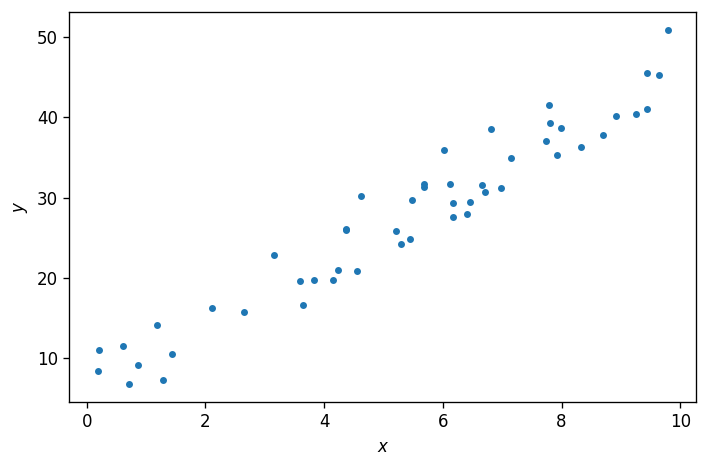

In [6]:
# Data visualisation (scatter plot)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,4), dpi =120)
ax.scatter(x , y, s=10)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.tight_layout()

### Simple linear model for a single feature.

$$
\boldsymbol{x} \cdot \boldsymbol{\theta}  = \theta_0 + \theta_1 x_1
$$


In [7]:
# Single feature linear hypothesis
def h_linear_single_feature(thetas, x):
    """
    Simple linear model for a single feature.

    Parameters
    ----------
    thetas : array-like
        [theta_0, theta_1] where theta_0 is the intercept and theta_1 is the slope.
    x : array-like
        Input feature, shape (m_samples,).
     :00
    Returns
    -------
    predictions : array
        Predicted values, shape (m_samples,).
    """
    return thetas[0] + thetas[1] * x

## 3- Functions

### 3.1- Cost Function: Mean Squared Error (MSE)

The  mission is to write a function calculating the cost (Mean Square Error).

In [8]:
def cost_function(thetas, x, y):
  h_theta = h_linear_single_feature(thetas, x)
  n=len(x)
  diff= (h_theta -y)**2
  mse  = np.sum(diff)/n
  return mse

### 3.2- Test of the Cost Function

In [9]:
x_test = np.array([1, 2, 3, 4])
y_test = np.array([2, 4, 6, 8])

# Set intercept term to zero
theta_0 = 0
thetas = np.zeros(2)
# List of values for theta_1 (the slope)
theta_1_candidates = [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5]
for each_theta in theta_1_candidates:
    # Call your cost function
    thetas[0] = theta_0
    thetas[1] = each_theta
    print(cost_function(thetas, x_test,y_test))

30.0
16.875
7.5
1.875
0.0
1.875
7.5
16.875


***I confirm those return values identical to the ones you calculated during class***

### 3.3- Residuals Function

Derivative of the cost function. I write another function, `get_residuals(...)`, which calculates the residuals, a term common to the partial derivatives of the cost, $\frac{\partial C(\boldsymbol{\theta})}{\partial \theta_0}$ and $\frac{\partial C(\boldsymbol{\theta})}{\partial \theta_1}$.



Let's remaind that the cost function derivatives is:

$$
\frac{\partial}{\partial \theta_j} C(\boldsymbol{\theta})
= \frac{1}{m} \sum_{i=1}^{m} \Big( h_\boldsymbol{\theta}(\boldsymbol{x}^{(i)}) - y^{(i)} \Big) x_j^{(i)}
$$


In [10]:
def get_residuals(thetas, x, y):
  h_theta = h_linear_single_feature(thetas, x)
  n=len(x)
  diff =  h_theta - y
  residual_0  = np.sum(diff)/n
  residual_1 =np.dot(x.T,diff)
  return residual_0,residual_1

In [11]:
def should_print_iteration(iter_index, first_step, second_step, index_changing_step):
    """
    Trigger a print if iter_index matches step rules:
    print every `first_step` iterations before `index_changing_step`,
    then every `second_step` iterations afterwards.
    """
    if first_step <= 0 or second_step <= 0:
        raise ValueError("Steps must be positive integers.")

    if iter_index == 0:
        return True  # Always print at the first iteration

    if iter_index <= index_changing_step:
        return iter_index % first_step == 0
    else:
        return iter_index % second_step == 0

### 1.4 Linear Regressor Loop

In [12]:
# Hyperparameters
alpha   = 0.0001
N       = 100000
epsilon =  1e-8 # tolerance threshold on gradients; exit if abs(gradients) < epsilon

# Initialization
theta_0 = 25
theta_1 = 0.5
# Check lists of x and y are of same length:
m = len(x)  # sample size
if m != len(y):
    raise ValueError("The lists of x and y values are not the same length!")

# Store parameter values for gradient descent visualizations
theta_0_grad_history = np.array([theta_0])
theta_1_grad_history = np.array([theta_1])

print("Starting gradient descent\n")

# -------------------
#  Start iterations
# -------------------
for iter_idx in range(N):
    # Call of the cost function
    cost = cost_function([theta_0,theta_1],x,y)
    # Let's determine gradients
    grad_theta_0,grad_theta_1= get_residuals([theta_0,theta_1], x, y)
    # Update of theta_0 and theta_1
    theta_0 -= alpha * grad_theta_0
    theta_1 -= alpha * grad_theta_1

    # Store thetas (for plotting)
    theta_0_grad_history = np.append(theta_0_grad_history, theta_0)
    theta_1_grad_history = np.append(theta_1_grad_history, theta_1)

    # Pretty print: every 10 iters until 100, then every 100 iters
    if should_print_iteration(iter_idx, 100, 1000, 1000):
        print(
            f"Iter {iter_idx:>4}\t"
            f"θ₀ = {theta_0:>7.3f}\t∂J/∂θ₀ = {grad_theta_0:>8.4f}\t"
            f"θ₁ = {theta_1:>7.3f}\t∂J/∂θ₁ = {grad_theta_1:>8.4f}\t"
            f"Cost = {cost:>8.5f}"
        )

    # Stop gradient descent when both gradients become smaller than epsilon
    if abs(grad_theta_0) < epsilon and abs(grad_theta_1) < epsilon:
       break
    # indicating convergence to a minimum.

print(f"\nEnd of gradient descent after {iter_idx+1} iterations")

Starting gradient descent

Iter    0	θ₀ =  25.000	∂J/∂θ₀ =   0.0950	θ₁ =   0.624	∂J/∂θ₁ = -1236.9552	Cost = 94.31365
Iter  100	θ₀ =  24.964	∂J/∂θ₀ =   3.7470	θ₁ =   1.186	∂J/∂θ₁ =  -0.5546	Cost = 77.21194
Iter  200	θ₀ =  24.927	∂J/∂θ₀ =   3.7394	θ₁ =   1.191	∂J/∂θ₁ =  -0.5534	Cost = 76.93158
Iter  300	θ₀ =  24.889	∂J/∂θ₀ =   3.7318	θ₁ =   1.197	∂J/∂θ₁ =  -0.5523	Cost = 76.65236
Iter  400	θ₀ =  24.852	∂J/∂θ₀ =   3.7242	θ₁ =   1.202	∂J/∂θ₁ =  -0.5512	Cost = 76.37427
Iter  500	θ₀ =  24.815	∂J/∂θ₀ =   3.7166	θ₁ =   1.208	∂J/∂θ₁ =  -0.5501	Cost = 76.09732
Iter  600	θ₀ =  24.778	∂J/∂θ₀ =   3.7091	θ₁ =   1.213	∂J/∂θ₁ =  -0.5489	Cost = 75.82149
Iter  700	θ₀ =  24.741	∂J/∂θ₀ =   3.7015	θ₁ =   1.219	∂J/∂θ₁ =  -0.5478	Cost = 75.54679
Iter  800	θ₀ =  24.704	∂J/∂θ₀ =   3.6940	θ₁ =   1.224	∂J/∂θ₁ =  -0.5467	Cost = 75.27320
Iter  900	θ₀ =  24.667	∂J/∂θ₀ =   3.6864	θ₁ =   1.230	∂J/∂θ₁ =  -0.5456	Cost = 75.00072
Iter 1000	θ₀ =  24.630	∂J/∂θ₀ =   3.6789	θ₁ =   1.235	∂J/∂θ₁ =  -0.5445	Cost = 74.72936
Ite

### 1.5 Visualize the gradient descent

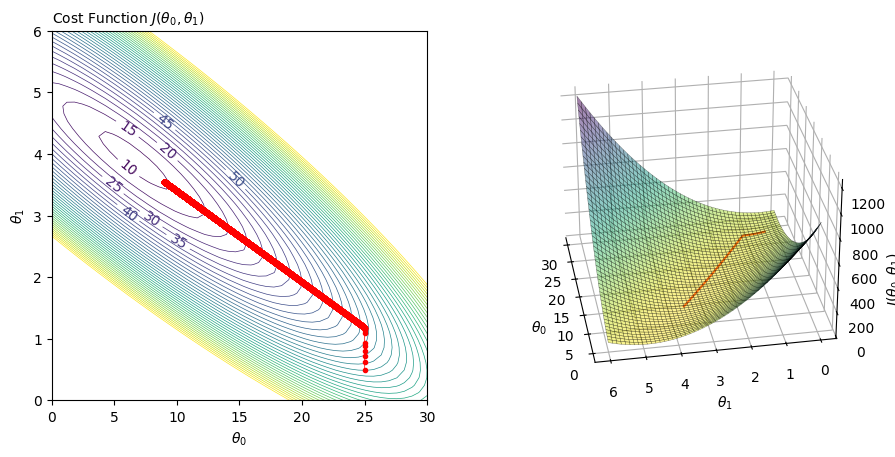

In [13]:
# Grid for 2D parameter space:
theta_0_grid = np.linspace(0, 30, 50)
theta_1_grid = np.linspace(0, 6, 50)

# Z values of costs for the surface:
meshed_theta_0, meshed_theta_1 = np.meshgrid(theta_0_grid, theta_1_grid)
meshed_costs = np.zeros_like(meshed_theta_0)  # Costs array

for i in range(meshed_theta_0.shape[0]):
    for j in range(meshed_theta_0.shape[1]):
        meshed_costs[i, j] = cost_function(
            [meshed_theta_0[i, j], meshed_theta_1[i, j]], x, y
        )

# Gradient descent: 5 first params then every 10 epochs
intermediary_theta_0_vals = np.concatenate(
    (theta_0_grad_history[0:5], theta_0_grad_history[5::5]), axis=None
)
intermediary_theta_1_vals = np.concatenate(
    (theta_1_grad_history[0:5], theta_1_grad_history[5::5]), axis=None
)

# Cost for selected intermediary weights (one per GD step)
intermediary_grad_cost_history = np.array(
    [
        cost_function([t0, t1], x, y)
        for t0, t1 in zip(intermediary_theta_0_vals, intermediary_theta_1_vals)
    ]
)

plt.rcParams.update(plt.rcParamsDefault)
fig = plt.figure(figsize=plt.figaspect(0.45))  # 16,4

# ==========================
#     Contour plot
# ==========================
plt.rcParams.update(plt.rcParamsDefault)

# Custom cost levels, from 5, step of 5, 200
levs = range(5, 200, 5)

ax = fig.add_subplot(1, 2, 1)

# Contour of theta parameter space:
CS = ax.contour(meshed_theta_0, meshed_theta_1, meshed_costs, levs, linewidths=0.5)
ax.clabel(CS, CS.levels[0:10], inline=1, fontsize=10, fmt="%d")

# Add the intermediary thetas from gradient descent:
ax.plot(intermediary_theta_0_vals, intermediary_theta_1_vals, marker=".", c="r", lw=0.5)
ax.set_xlabel("$\\theta_0$")
ax.set_ylabel("$\\theta_1$")
plt.title("Cost Function $J(\\theta_0, \\theta_1)$", loc="left", fontsize=10)

# ==========================
#     3D plot
# ==========================
ax = fig.add_subplot(1, 2, 2, projection="3d")

# 3D surface of cost vs (theta  0, theta 1):
surf = ax.plot_surface(
    meshed_theta_0,
    meshed_theta_1,
    meshed_costs,
    cmap="viridis_r",
    linewidth=0.3,
    alpha=0.5,
    edgecolor="k",
)

# Path of intermediary thetas from gradient descent:
ax.plot(
    intermediary_theta_0_vals,
    intermediary_theta_1_vals,
    intermediary_grad_cost_history,
    c="r",
)

ax.set_xlabel("$\\theta_0$")
ax.set_ylabel("$\\theta_1$")
ax.set_zlabel("$J(\\theta_0, \\theta_1)$", rotation=90)
ax.azim = 170
ax.elev = 30
ax.xaxis.set_rotate_label(False)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_rotate_label(False)
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_rotate_label(False)
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

plt.show()

###1.6 Let’s check with NumPy

In [14]:
slope, intercept = np.polyfit(x, y, deg=1)

In [15]:
print(slope)
print(intercept)

3.9062587362934416
6.580520907666924


## **Part II: Generalizing to $n$ features with vectorized gradient descent**

## 1- Functions with $n$ features

### 1-1- Multiple feature linear hypothesis

### Multiple linear model for a single feature.

$$
\boldsymbol{x} \cdot \boldsymbol{\theta}  = \theta_0 + \theta_1 x_1 + \cdots + \theta_n x_n
$$

In [16]:
def h_linear_multiple_feature(x,thetas):
    return np.dot(x,thetas)

### 1-2- Multiple feature Cost functions

In [17]:
def cost_function_multiple_feature(thetas, x, y):
  h_theta = h_linear_multiple_feature(x, thetas)
  n,m = np.shape(x)
  diff= (h_theta -y.reshape(1,-1))**2
  mse  = np.sum(diff)/n
  return mse

### 1-3- Multiple feature linear hypothesis

In [18]:
def get_residuals_multiple_feature(thetas, x, y):
  h_theta = h_linear_multiple_feature(x,thetas)
  n,m = np.shape(x)
  diff =  h_theta - y
  residual_0  = np.sum(diff)/n
  residuals  = (x*diff.reshape(-1, 1)).sum(axis=0)/n # Reshape diff for element-wise multiplication
  return residual_0,residuals

## 2- Main learning fonction

In [19]:
def learning(x_train, y_train,N_iterative = 10000,learning_rate = 0.005,espsilon = 1e-8):
  #
  n,m= np.shape(x_train)
  x_train = np.hstack((np.ones((n,1)),x_train))
  # Check lists of x and y are of same length:
  if n != len(y_train):
      raise ValueError("The lists of x and y values are not the same length!")

  # Initialize thetas with the correct shape
  theta_new = np.ones(m+1)

  # Store parameter values for gradient descent visualizations
  theta_grad_history = np.array([theta_new])

  print("Starting gradient descent\n")

  for iter_idx in range(N_iterative):
    # Single feature linear hypothesis
    cost = cost_function_multiple_feature(theta_new,x_train,y_train)
    #
    grad_theta_0,grad_thetas= get_residuals_multiple_feature(theta_new, x_train, y_train)
    #
    #update_value_0 = theta_new[0] - learning_rate * grad_theta_0
    update_values = theta_new - learning_rate * grad_thetas
    theta_new = update_values
    #
    theta_grad_history = np.append(theta_grad_history, [theta_new], axis=0) # Append as a new row
    # Pretty print: every 10 iters until 100, then every 100 iters
    if should_print_iteration(iter_idx, 100, 1000, 1000):
        print(
            f"Iter {iter_idx:>4}\t"
            f"θ₀ = {theta_new[0]:>7.3f}\t∂J/∂θ₀ = {grad_thetas[0]:>8.4f}\t"
            f"θ1 = {theta_new[1]:>7.3f}\t∂J/∂θ1 = {grad_thetas[1]:>8.4f}\t"
            f"θ2 = {theta_new[2]:>7.3f}\t∂J/∂θ2 = {grad_thetas[2]:>8.4f}\t"
            f"θ3 = {theta_new[3]:>7.3f}\t∂J/∂θ3 = {grad_thetas[3]:>8.4f}\t"
            f"Cost = {cost:>8.5f}"
        )
    if np.all(np.abs(grad_thetas) < epsilon):
      print(f"Stop at iteration {i}, gradient too small")
      break
  return cost,theta_grad_history

In [20]:
x_test = np.array([[1, 2,1, 2],[1, 7,1, 2],[1, 2,1, 2],[9, 2,1, 2],[1, 2,1, 2]])
thetas = np.array([1, 2,1, 2])
y = np.array([1, 4, 6, 4, 4])
cost,theta_grad_history =learning( x_test, y)

Starting gradient descent

Iter    0	θ₀ =   0.971	∂J/∂θ₀ =   5.8000	θ1 =   0.883	∂J/∂θ1 =  23.4000	θ2 =   0.902	∂J/∂θ2 =  19.6000	θ3 =   0.971	∂J/∂θ3 =   5.8000	Cost = 46.20000
Iter  100	θ₀ =   0.828	∂J/∂θ₀ =  -0.0867	θ1 =   0.085	∂J/∂θ1 =   0.0417	θ2 =   0.176	∂J/∂θ2 =   0.1093	θ3 =   0.828	∂J/∂θ3 =  -0.0867	Cost =  2.59293
Iter  200	θ₀ =   0.862	∂J/∂θ₀ =  -0.0530	θ1 =   0.068	∂J/∂θ1 =   0.0261	θ2 =   0.133	∂J/∂θ2 =   0.0659	θ3 =   0.862	∂J/∂θ3 =  -0.0530	Cost =  2.55549
Iter  300	θ₀ =   0.883	∂J/∂θ₀ =  -0.0323	θ1 =   0.058	∂J/∂θ1 =   0.0159	θ2 =   0.107	∂J/∂θ2 =   0.0402	θ3 =   0.883	∂J/∂θ3 =  -0.0323	Cost =  2.54157
Iter  400	θ₀ =   0.895	∂J/∂θ₀ =  -0.0197	θ1 =   0.051	∂J/∂θ1 =   0.0097	θ2 =   0.091	∂J/∂θ2 =   0.0245	θ3 =   0.895	∂J/∂θ3 =  -0.0197	Cost =  2.53640
Iter  500	θ₀ =   0.903	∂J/∂θ₀ =  -0.0120	θ1 =   0.048	∂J/∂θ1 =   0.0059	θ2 =   0.082	∂J/∂θ2 =   0.0149	θ3 =   0.903	∂J/∂θ3 =  -0.0120	Cost =  2.53447
Iter  600	θ₀ =   0.908	∂J/∂θ₀ =  -0.0073	θ1 =   0.045	∂J/∂θ1 =   0.0036	θ

## 3- Training on a diabetes dataset

In [21]:
from sklearn.datasets import load_diabetes


In [22]:
# Load the dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target


In [23]:
# Put into a pandas DataFrame
df = pd.DataFrame(X, columns=diabetes.feature_names)
df["target"] = y

print("Dataset preview:")
print(df.head())


Dataset preview:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [24]:
# Prepare the features with the bias column
X = np.c_[np.ones(X.shape[0]), X] # Add the bias for theta_0
y = y

# Initialize the parameters
thetas = np.zeros(X.shape[1])

# Callof learning function
cost, theta_grad_history = learning(X, y)

print("Final cost :", cost)
print("Last parameters:", theta_grad_history[-1])

Starting gradient descent

Iter    0	θ₀ =   1.751	∂J/∂θ₀ = -150.1335	θ1 =   1.751	∂J/∂θ1 = -150.1335	θ2 =   1.003	∂J/∂θ2 =  -0.6817	θ3 =   1.001	∂J/∂θ3 =  -0.1532	Cost = 28450.75365
Iter  100	θ₀ =  48.865	∂J/∂θ₀ = -54.9537	θ1 =  48.865	∂J/∂θ1 = -54.9537	θ2 =   1.343	∂J/∂θ2 =  -0.6779	θ3 =   1.077	∂J/∂θ3 =  -0.1503	Cost = 8911.28944
Iter  200	θ₀ =  66.110	∂J/∂θ₀ = -20.1148	θ1 =  66.110	∂J/∂θ1 = -20.1148	θ2 =   1.681	∂J/∂θ2 =  -0.6741	θ3 =   1.151	∂J/∂θ3 =  -0.1473	Cost = 6276.83018
Iter  300	θ₀ =  72.422	∂J/∂θ₀ =  -7.3627	θ1 =  72.422	∂J/∂θ1 =  -7.3627	θ2 =   2.017	∂J/∂θ2 =  -0.6703	θ3 =   1.224	∂J/∂θ3 =  -0.1444	Cost = 5907.43166
Iter  400	θ₀ =  74.733	∂J/∂θ₀ =  -2.6950	θ1 =  74.733	∂J/∂θ1 =  -2.6950	θ2 =   2.352	∂J/∂θ2 =  -0.6665	θ3 =   1.295	∂J/∂θ3 =  -0.1414	Cost = 5841.63772
Iter  500	θ₀ =  75.578	∂J/∂θ₀ =  -0.9864	θ1 =  75.578	∂J/∂θ1 =  -0.9864	θ2 =   2.684	∂J/∂θ2 =  -0.6627	θ3 =   1.365	∂J/∂θ3 =  -0.1385	Cost = 5816.65196
Iter  600	θ₀ =  75.888	∂J/∂θ₀ =  -0.3611	θ1 =  75.888	∂J/∂

## 4- Thank you !!!!!!!!!!!!!